# Notebook 07: Exploring the existing results

**Goal (about 1.5 hours):** read the results Michael's pipeline produced for every station, understand the bookkeeping (why each event did or did not yield a number), and make the standard summary plots: histograms and rose diagrams.

From here on you work with the results CSVs in `results/`. One row per catalog event per station; nothing is dropped, the `stage` column says where each event stopped.

In [1]:
# --- setup: make the repo importable and keep figures inline ---
import sys, warnings
from pathlib import Path
REPO = Path.cwd().parent if (Path.cwd() / "../rainier_sws").exists() else Path.cwd()
sys.path.insert(0, str(REPO))
warnings.filterwarnings("ignore")
%matplotlib inline
import numpy as np, pandas as pd, matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
from rainier_sws import paths, data, measure, quality, stats
print("repo:", REPO)

repo: /home/claude/rainier-sws-tutorials


In [2]:
import glob
STATIONS = ["STAR", "RCM", "MILD", "LON", "PANH", "OBSR", "PARA", "RER", "COPP"]
res = {s: pd.read_csv(paths.station_results_csv(s)) for s in STATIONS}
res["STAR"].head(3)

,evid,station,stage,back_azimuth,rectilinearity,incidence_angle_jurkevics,incidence_angle,travel_time_s,snr_horizontal,filter_band,...,phi_error,dt_error,quality,dominant_period,success,pct_anisotropy,datetime,magnitude,error,traceback
0,61504363,STAR,ok,80.287841,0.644608,36.952068,25.207142,1.822654,2.539548,"(5.0, 15.0)",...,2.0,0.01,0.053923,0.091545,True,1.097301,2025-07-08T15:24:37.709999084+00:00,-0.44,NaN,NaN
1,61504373,STAR,fail_snr,85.530214,0.699192,36.697966,25.044442,1.650617,1.726128,"(10.0, 45.0)",...,NaN,NaN,NaN,NaN,NaN,NaN,2025-07-08T15:38:45.819999695+00:00,0.31,NaN,NaN
2,61504388,STAR,ok,87.119563,0.729471,38.116861,26.039246,1.766310,2.551091,"(3.0, 5.0)",...,31.0,0.03,0.000000,0.214825,True,2.264608,2025-07-08T15:47:51.469997406+00:00,0.36,NaN,NaN


## 1. The funnel: attempted, successful, grade 3

Three numbers per station. "Successful" means the pipeline reached the end and returned finite phi and dt. "Grade 3" means the measurement also passed the post-processing quality filter (`rainier_sws/quality.py`). Compare with the table in the onboarding document.

In [3]:
funnel = pd.DataFrame({s: quality.funnel(r) for s, r in res.items()}).T
funnel

,attempted,successful,grade3
STAR,903,709,121
RCM,509,274,45
MILD,685,107,25
LON,1172,670,42
PANH,414,0,0
OBSR,139,1,0
PARA,749,0,0
RER,450,0,0
COPP,348,0,0


Text(0.5, 1.0, "Where each station's events stopped")

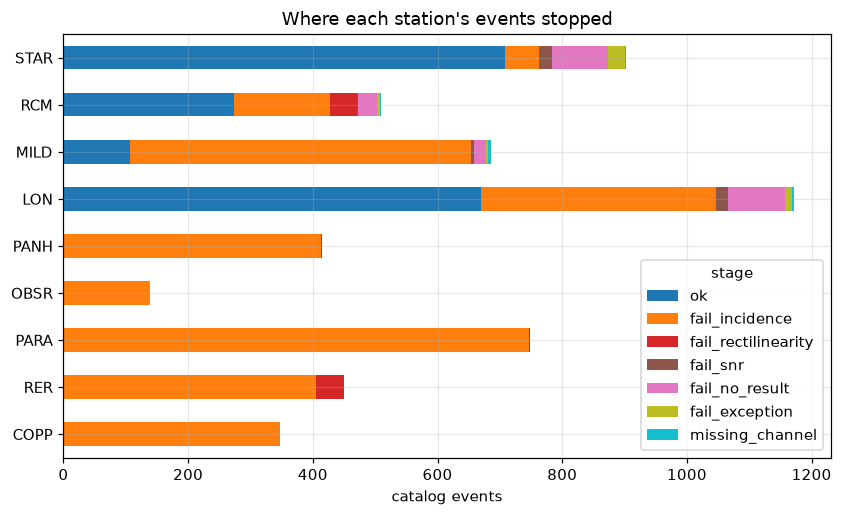

In [4]:
stages = pd.DataFrame({s: quality.stage_counts(r) for s, r in res.items()}).fillna(0).astype(int).T
stages = stages[["ok", "fail_incidence", "fail_rectilinearity", "fail_snr", "fail_no_result", "fail_exception", "missing_channel"]]
ax = stages.plot.barh(stacked=True, figsize=(9, 5), colormap="tab10"); ax.invert_yaxis()
ax.set_xlabel("catalog events"); ax.set_title("Where each station's events stopped")

This is the picture behind a line in the onboarding doc: PANH, OBSR, PARA, RER and COPP produce almost nothing, and the plot shows exactly why, **every event fails the incidence-angle gate**. That is a known, understood outcome, not a bug to find. These stations sit far enough from the swarm that, through the velocity model used for ray tracing, every S wave arrives at more than 45 degrees from vertical.

Whether that is the *right* conclusion depends on two choices made upstream: the velocity model that produced the angles, and the 45-degree cutoff itself. Both are thresholds to benchmark (notebook 08), not facts.

## 2. Distributions of the measured quantities (STAR)

Before any filtering, look at everything the pipeline returned. Histograms of phi, dt, their formal errors, the quality score and SNR tell you what the raw population looks like and where the grade-3 cuts fall.

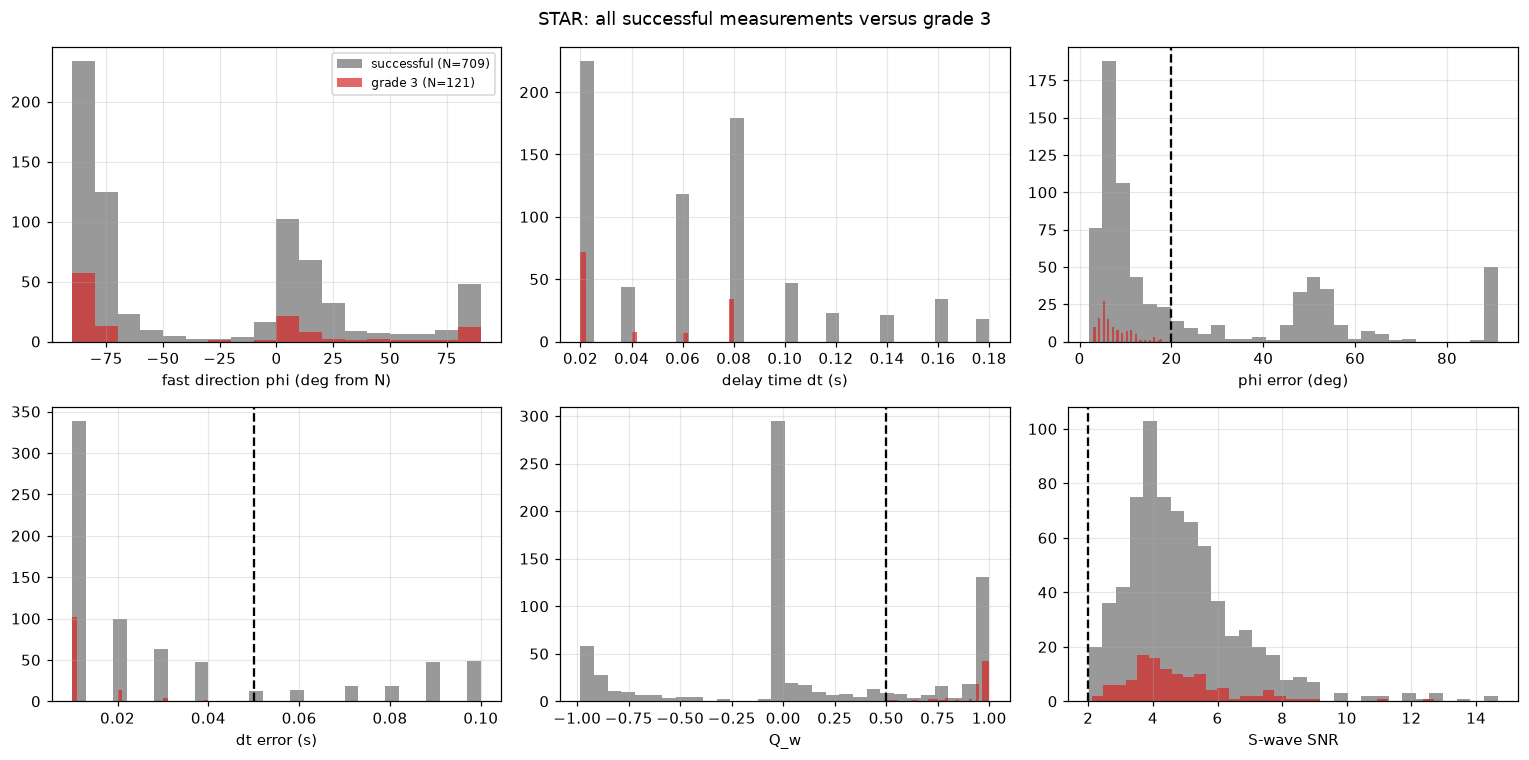

In [5]:
def hist_panel(r, title):
    ok = quality.successful(r); g3 = quality.grade3(r)
    cols = [("phi", "fast direction phi (deg from N)", None), ("dt", "delay time dt (s)", None),
            ("phi_error", "phi error (deg)", 20), ("dt_error", "dt error (s)", 0.05),
            ("quality", "Q_w", 0.5), ("snr_horizontal", "S-wave SNR", 2.0)]
    fig, axes = plt.subplots(2, 3, figsize=(14, 7))
    for ax, (c, lab, cut) in zip(axes.ravel(), cols):
        bins = 30 if c != "phi" else np.arange(-90, 91, 10)
        ax.hist(ok[c].dropna(), bins=bins, color="0.6", label=f"successful (N={len(ok)})")
        ax.hist(g3[c].dropna(), bins=bins, color="tab:red", alpha=0.7, label=f"grade 3 (N={len(g3)})")
        if cut is not None: ax.axvline(cut, color="k", ls="--")
        ax.set_xlabel(lab)
    axes[0, 0].legend(fontsize=8); fig.suptitle(title); plt.tight_layout()
hist_panel(res["STAR"], "STAR: all successful measurements versus grade 3")

Read the panels together. Many successful measurements have large phi errors or low Q_w; the grade-3 filter removes most of them. What survives has dt mostly at 0.01 to 0.03 s (one to three samples!) and phi clustered near plus or minus 90, i.e. east-west. Whether a one-sample delay is physically meaningful is a fair question to keep asking.

## 3. Rose diagrams

The standard display for fast directions is a rose diagram: a histogram on a circle, mirrored because phi is an axis. Here is a small function; use it for every station from now on.

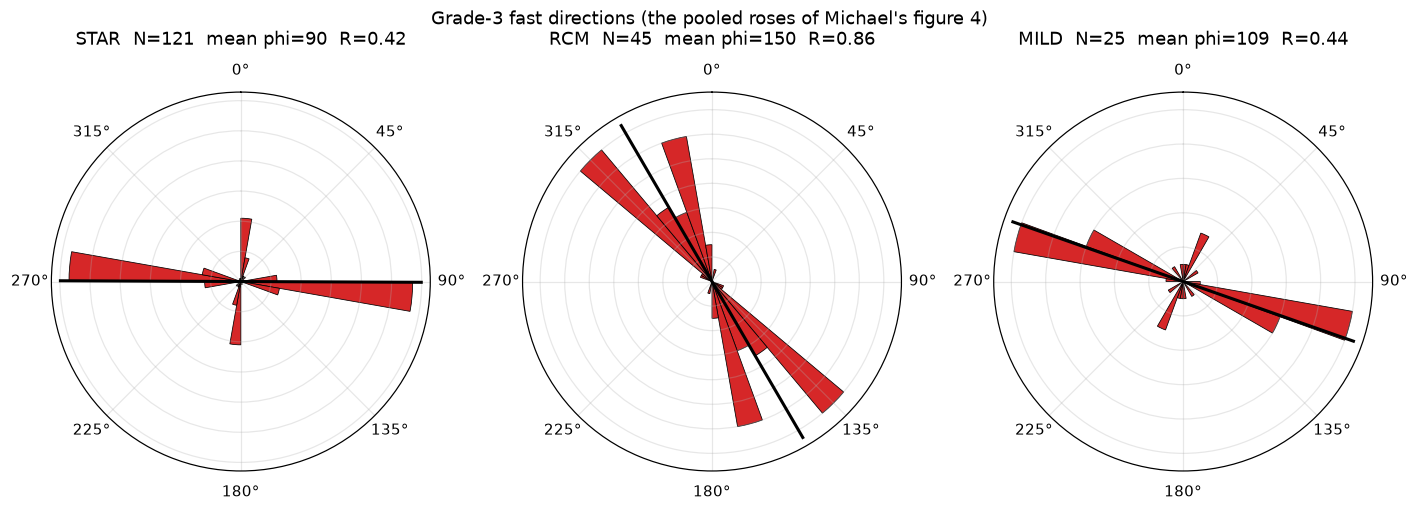

In [6]:
def rose(ax, phi_deg, bin_deg=10, color="tab:red", title=""):
    phi = measure.phi_0_180(np.asarray(phi_deg))
    bins = np.arange(0, 181, bin_deg)
    counts, _ = np.histogram(phi, bins=bins)
    theta = np.deg2rad(np.concatenate([bins[:-1], bins[:-1] + 180]))
    ax.bar(theta, np.concatenate([counts, counts]), width=np.deg2rad(bin_deg), bottom=0, color=color, edgecolor="k", lw=0.5, align="edge")
    ax.set_theta_zero_location("N"); ax.set_theta_direction(-1); ax.set_yticklabels([])
    ax.set_title(title, pad=12)

fig = plt.figure(figsize=(13, 4.5))
for i, s in enumerate(["STAR", "RCM", "MILD"]):
    g3 = quality.grade3(res[s])
    m, R = stats.axial_mean(g3.phi)
    ax = fig.add_subplot(1, 3, i + 1, projection="polar")
    rose(ax, g3.phi, title=f"{s}  N={len(g3)}  mean phi={m:.0f}  R={R:.2f}")
    ax.plot([np.deg2rad(m), np.deg2rad(m + 180)], [ax.get_ylim()[1]] * 2, "k-", lw=2)
fig.suptitle("Grade-3 fast directions (the pooled roses of Michael's figure 4)")
plt.tight_layout()

`R` is the mean resultant length (0 = no preferred axis, 1 = all identical). STAR's roughly east-west preference is clear; RCM and MILD have fewer events and broader spreads. The black bar is the axial mean. None of these has an error bar yet; that is notebook 08.

## 4. Does the answer depend on where the earthquake is?

Plot grade-3 phi against back azimuth. If fast directions were a property of the rock under the station they would not depend on where the wave came from. If they track the back azimuth, suspect nulls or ray-path effects.

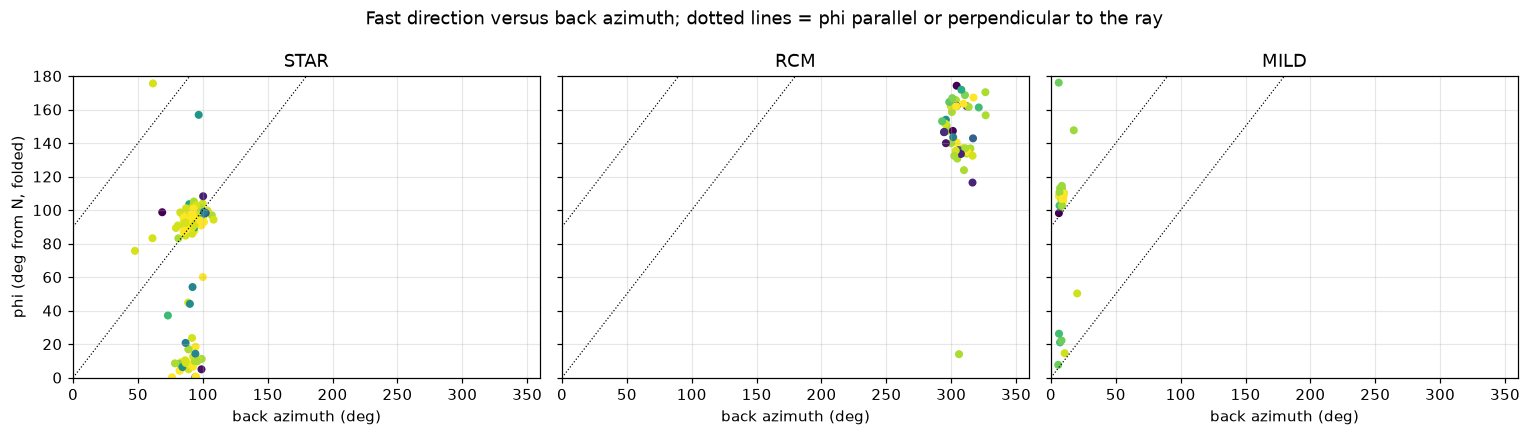

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, s in zip(axes, ["STAR", "RCM", "MILD"]):
    g3 = quality.grade3(res[s])
    ax.scatter(g3.back_azimuth, measure.phi_0_180(g3.phi), c=g3.quality, cmap="viridis", s=18)
    for off in (0, 90, 180):
        ax.plot([0, 360], [off, off + 360], "k:", lw=0.8)
    ax.set_xlabel("back azimuth (deg)"); ax.set_title(s); ax.set_ylim(0, 180); ax.set_xlim(0, 360)
axes[0].set_ylabel("phi (deg from N, folded)")
fig.suptitle("Fast direction versus back azimuth; dotted lines = phi parallel or perpendicular to the ray")
plt.tight_layout()

At STAR almost all rays come from one back azimuth (about 90 degrees), so this plot cannot distinguish "the rock is anisotropic" from "phi equals the back azimuth". That is a limitation of the geometry, not of the method, and it is why adding stations with different geometry matters.

## 5. Time: does anything change during the swarm?

The scientific question is whether anisotropy changed as fluids moved. Plot grade-3 dt and phi against origin time with a running median.

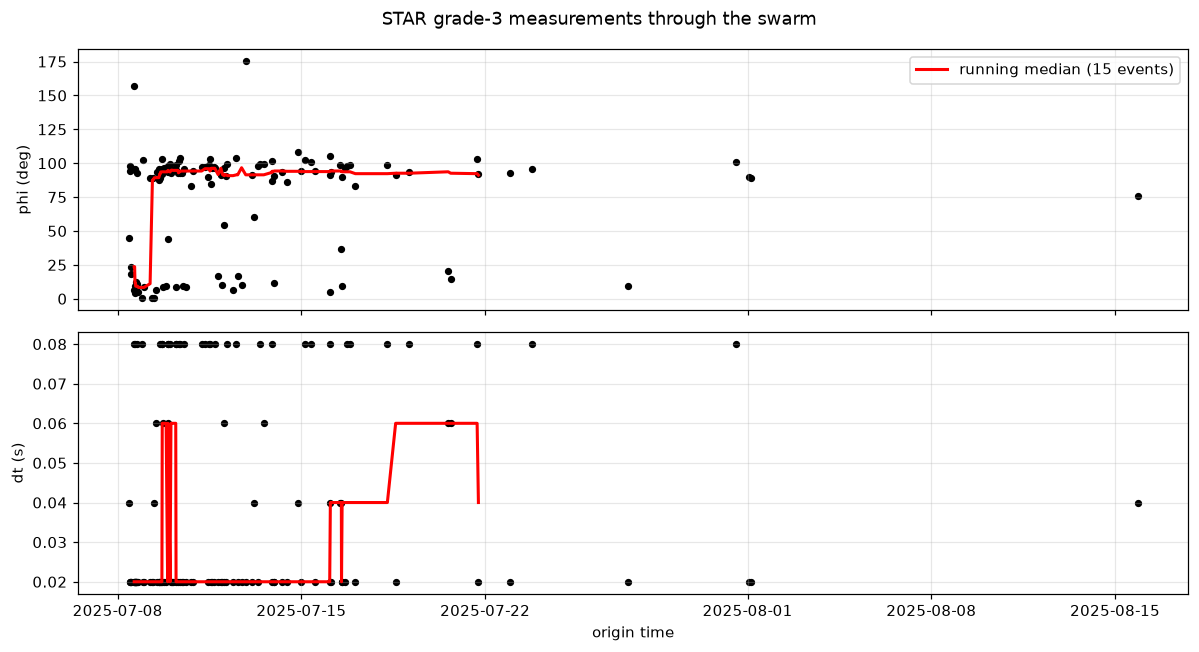

In [8]:
g3 = quality.grade3(res["STAR"]).copy()
g3["time"] = pd.to_datetime(g3.datetime, utc=True, format="ISO8601")
g3 = g3.sort_values("time")
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
axes[0].scatter(g3.time, measure.phi_0_180(g3.phi), s=14, c="k"); axes[0].set_ylabel("phi (deg)")
axes[1].scatter(g3.time, g3.dt, s=14, c="k"); axes[1].set_ylabel("dt (s)")
for ax, col in zip(axes, [measure.phi_0_180(g3.phi), g3.dt]):
    ax.plot(g3.time, pd.Series(np.asarray(col)).rolling(15, center=True).median().values, "r-", lw=2, label="running median (15 events)")
axes[0].legend(); axes[1].set_xlabel("origin time"); fig.suptitle("STAR grade-3 measurements through the swarm")
plt.tight_layout()

With 121 points and errors of several degrees and 0.01 s, is any trend here distinguishable from noise? You cannot answer that without an uncertainty estimate, which is the next notebook.

## 6. Exercises

1. Make `hist_panel` for RCM and MILD. Which grade-3 cut removes the most events at each station?
2. Add LON to the rose figure. LON used the data-derived (Jurkevics) incidence angle instead of the ray-traced one; does its rose look like the others?
3. For PANH, histogram `incidence_angle` (ray-traced) and `incidence_angle_jurkevics`. How far above 45 degrees are the events? Would a 60-degree cutoff rescue any? (Careful: rescued is not the same as valid.)
4. Compute percent anisotropy (`pct_anisotropy`, dt divided by travel time) summary statistics per station for grade 3. Which station is "most anisotropic", and do you believe it given the sample sizes?

Next: `08_uncertainty_and_thresholds.ipynb`.